# Insurance Cost Prediction

## Exploratory Data Analysis (EDA)

### 1. Import Libraries

### 2. Load Dataset

### 3. Dataset Overview

### 4. Data Quality Checks

### 5. Distribution Analysis

### 6. Outlier Detection

### 7. Correlation Analysis

### 8. Relationship with PremiumPrice

### 9. Key Findings

### 10. Next Steps

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [ ]:
# Load Dataset
df = pd.read_csv('../data/insurance.csv')

In [ ]:
# Dataset Overview
df.head()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
0,45,0,0,0,0,155,57,0,0,0,25000
1,60,1,0,0,0,180,73,0,0,0,29000
2,36,1,1,0,0,158,59,0,0,1,23000
3,52,1,1,0,1,183,93,0,0,2,28000
4,38,0,0,0,1,166,88,0,0,1,23000


In [49]:
# Data Quality Check
df.shape

(986, 11)

In [50]:
# Data Summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Age                      986 non-null    int64
 1   Diabetes                 986 non-null    int64
 2   BloodPressureProblems    986 non-null    int64
 3   AnyTransplants           986 non-null    int64
 4   AnyChronicDiseases       986 non-null    int64
 5   Height                   986 non-null    int64
 6   Weight                   986 non-null    int64
 7   KnownAllergies           986 non-null    int64
 8   HistoryOfCancerInFamily  986 non-null    int64
 9   NumberOfMajorSurgeries   986 non-null    int64
 10  PremiumPrice             986 non-null    int64
dtypes: int64(11)
memory usage: 84.9 KB


In [51]:
# Data Summary
df.describe()

,Age,Diabetes,BloodPressureProblems,AnyTransplants,AnyChronicDiseases,Height,Weight,KnownAllergies,HistoryOfCancerInFamily,NumberOfMajorSurgeries,PremiumPrice
count,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000,986.000000
mean,41.745436,0.419878,0.468560,0.055781,0.180527,168.182556,76.950304,0.215010,0.117647,0.667343,24336.713996
std,13.963371,0.493789,0.499264,0.229615,0.384821,10.098155,14.265096,0.411038,0.322353,0.749205,6248.184382
min,18.000000,0.000000,0.000000,0.000000,0.000000,145.000000,51.000000,0.000000,0.000000,0.000000,15000.000000
25%,30.000000,0.000000,0.000000,0.000000,0.000000,161.000000,67.000000,0.000000,0.000000,0.000000,21000.000000
50%,42.000000,0.000000,0.000000,0.000000,0.000000,168.000000,75.000000,0.000000,0.000000,1.000000,23000.000000
75%,53.000000,1.000000,1.000000,0.000000,0.000000,176.000000,87.000000,0.000000,0.000000,1.000000,28000.000000
max,66.000000,1.000000,1.000000,1.000000,1.000000,188.000000,132.000000,1.000000,1.000000,3.000000,40000.000000


In [52]:
# Missing Values Check
df.isna().sum()

Age                        0
Diabetes                   0
BloodPressureProblems      0
AnyTransplants             0
AnyChronicDiseases         0
Height                     0
Weight                     0
KnownAllergies             0
HistoryOfCancerInFamily    0
NumberOfMajorSurgeries     0
PremiumPrice               0
dtype: int64

In [53]:
df.duplicated().sum()

np.int64(0)

Observation from Summary Statistics:

* The dataset has 986 records with no missing values for Age, and no duplicates found.

* PremiumPrice has a mean of ~24,337 and ranges from 15,000 to 40,000, showing wide variation.

* Age averages ~42 years, with a spread from 18 to 66, and is strongly linked to premiums.

* Binary health conditions like Diabetes (~42% prevalence), BloodPressureProblems (~47%), and AnyChronicDiseases (~18%) are present in notable proportions.

* AnyTransplants is rare (~6%), while KnownAllergies (~21%) and HistoryOfCancerInFamily (~12%) occur less frequently.

* Height and Weight show normal ranges (145–188 cm, 51–132 kg) but weak correlation with premiums.

* NumberOfMajorSurgeries averages ~0.67, with most customers having 0–1 surgeries, and a maximum of 3.

The dataset is clean, premiums rise with age, and serious health conditions (especially diabetes, blood pressure problems, and surgeries) are key drivers of higher insurance costs.

# Exploratory Data Analysis

# Univariate Analysis

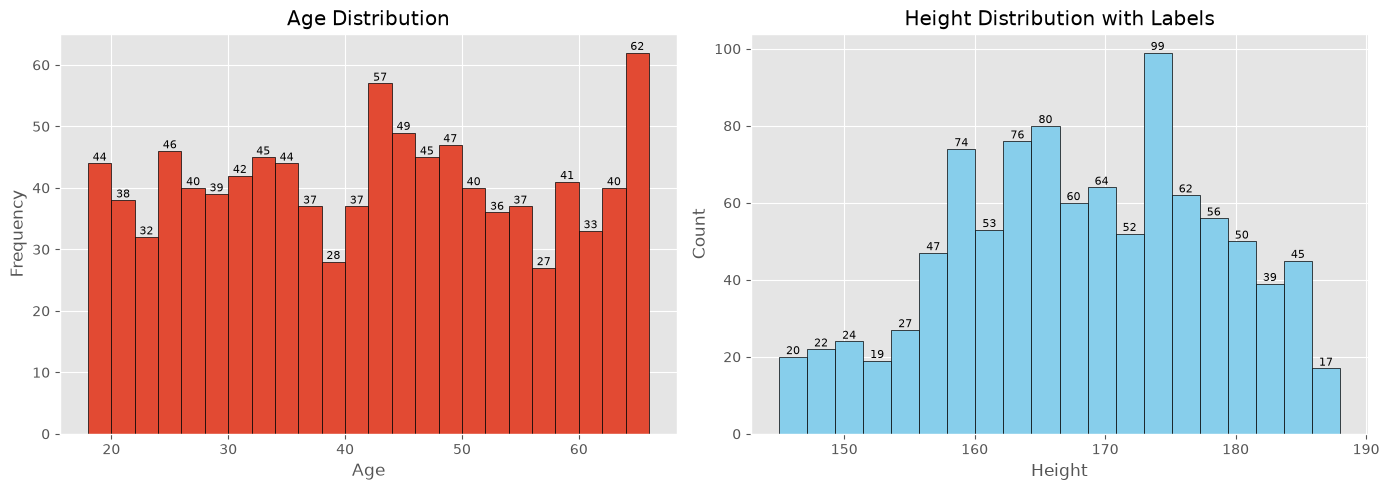

In [ ]:
# Continuous Variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Age Distribution ---
counts_age, bins_age, patches_age = axes[0].hist(df["Age"], bins=24, edgecolor='black')
for count, patch in zip(counts_age, patches_age):
    axes[0].text(patch.get_x() + patch.get_width()/2, count,
                 str(int(count)), ha='center', va='bottom', fontsize=8)

axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

# --- Height Distribution ---
counts_height, bins_height, patches_height = axes[1].hist(df["Height"], bins=20, color='skyblue', edgecolor='black')
for count, patch in zip(counts_height, patches_height):
    axes[1].text(patch.get_x() + patch.get_width()/2, count,
                 str(int(count)), ha='center', va='bottom', fontsize=8)

axes[1].set_title("Height Distribution with Labels")
axes[1].set_xlabel("Height")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


Observation:

* The Age chart shows people spread across many ages, but the biggest group 62 people are at age 64-66 then followed by 42-44 age. This means hightest count of people in the dataset are older.

* The Height chart looks more like a bell curve, with most people around 173 cms tall. Very short and very tall people are fewer.

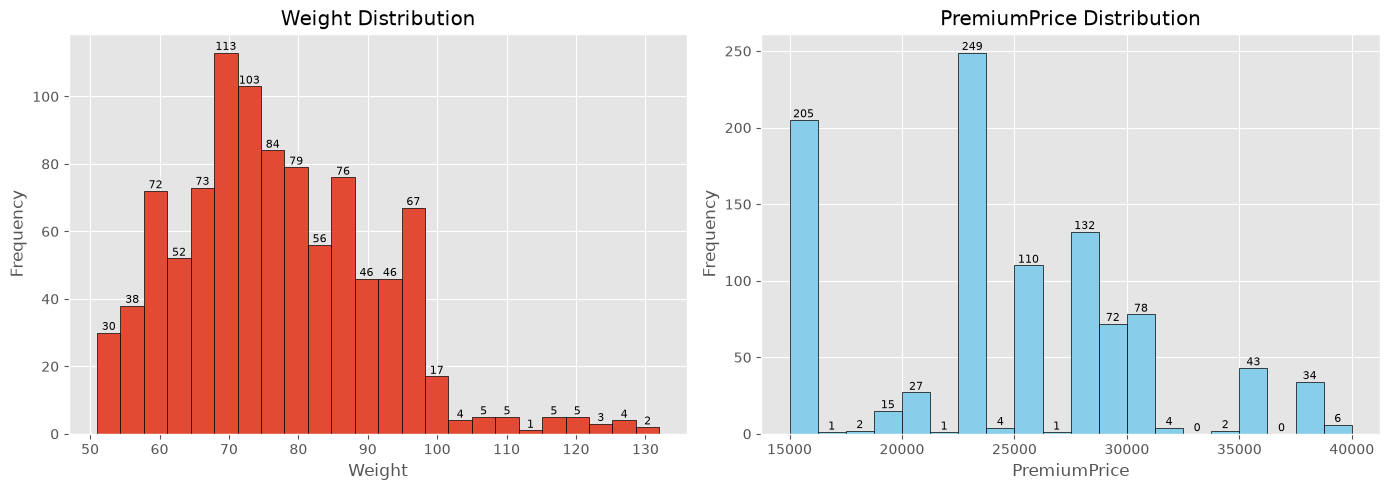

In [ ]:
# Continuous Variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Weight Distribution ---
counts_weight, bins_weight, patches_weight = axes[0].hist(df["Weight"], bins=24, edgecolor='black')
for count, patch in zip(counts_weight, patches_weight):
    axes[0].text(patch.get_x() + patch.get_width()/2, count,
                 str(int(count)), ha='center', va='bottom', fontsize=8)

axes[0].set_title("Weight Distribution")
axes[0].set_xlabel("Weight")
axes[0].set_ylabel("Frequency")

# --- PremiumPrice Distribution ---
counts_premium, bins_premium, patches_premium = axes[1].hist(df["PremiumPrice"], bins=20, color='skyblue', edgecolor='black')
for count, patch in zip(counts_premium, patches_premium):
    axes[1].text(patch.get_x() + patch.get_width()/2, count,
                 str(int(count)), ha='center', va='bottom', fontsize=8)

axes[1].set_title("PremiumPrice Distribution")
axes[1].set_xlabel("PremiumPrice")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Observation:

* The Weight distribution charts shows that most people weight are lied in between 68-82 kgs. Fewer people are from 100 and above kgs. 

* The Premium price distribution is not evenly spreaded. However, the peaks of premium price are around 23000 and 16000 in currency.

# Binary Variable Analysis

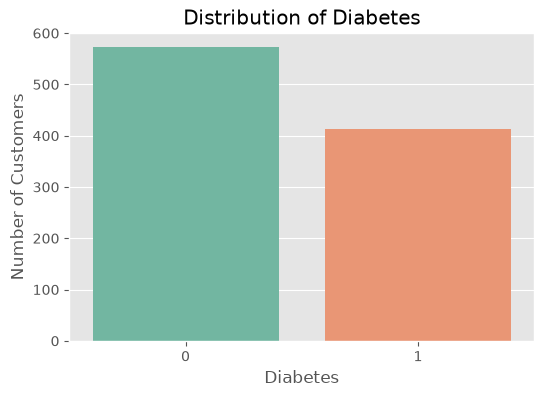

In [ ]:
# Distribution of Diabetes
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Diabetes", hue="Diabetes", palette="Set2", legend=False)
plt.title("Distribution of Diabetes")
plt.xlabel("Diabetes")
plt.ylabel("Number of Customers")
plt.show()

Observation:

* The bar chart shows the distribution of diabetes status among customers.

* A larger group of customers fall under Diabetes = 0 (no diabetes), with counts around 580.

* A smaller but still substantial group fall under Diabetes = 1 (with diabetes), with counts around 420.

This indicates that while the majority of customers do not have diabetes, a significant proportion (nearly 40%) of the dataset does.

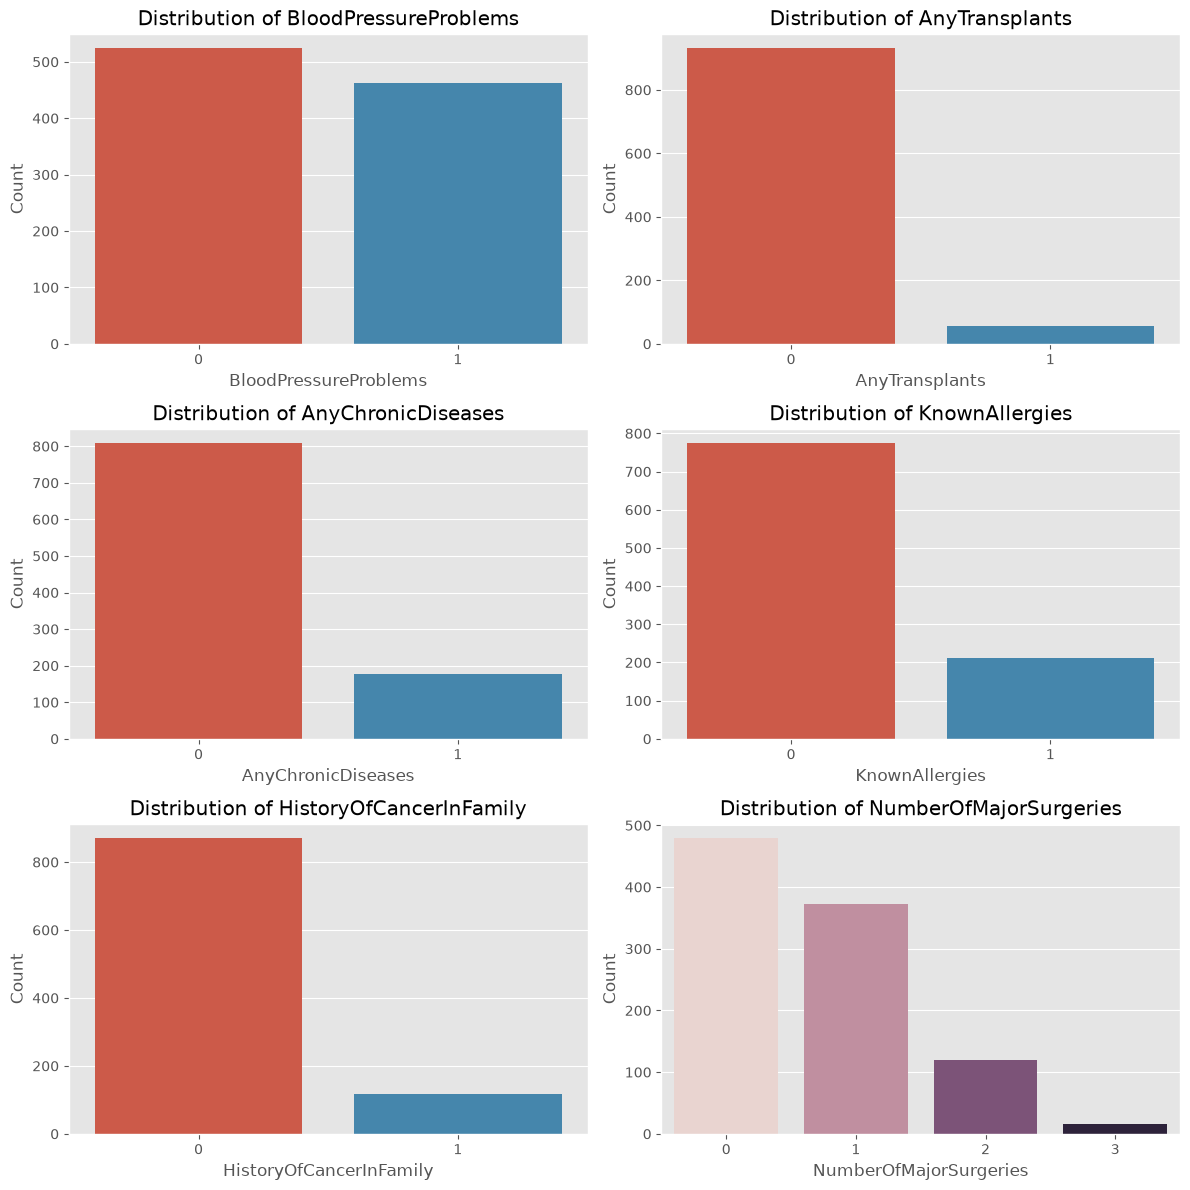

In [75]:
bva = ['BloodPressureProblems', 'AnyTransplants',
       'AnyChronicDiseases', 'KnownAllergies',
       'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries']

# Create subplots: 3 rows, 2 columns
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, col in enumerate(bva):
    sns.countplot(x=col, data=df, hue=col, ax=axes[i], legend=False)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Adjust layout
plt.tight_layout()
plt.show()

Observation:

* Most customers in the dataset fall into the “0” category (no health issue) for variables like BloodPressureProblems, AnyTransplants, AnyChronicDiseases, KnownAllergies, and HistoryOfCancerInFamily.

* The “1” category (presence of condition) is consistently smaller, showing that fewer individuals report these health issues.

* For NumberOfMajorSurgeries, most customers have 0 surgeries, with counts decreasing steadily as the number of surgeries increases (1, 2, 3).

Overall, the dataset indicates that serious medical conditions and surgeries are relatively rare, while the majority of customers are healthier.

# Outlier Detection using Boxplots

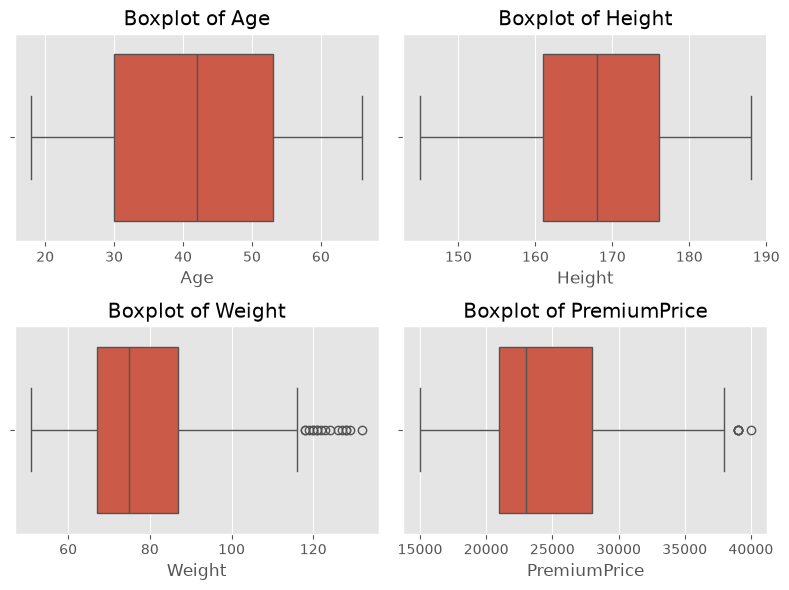

In [ ]:
continuous_cols = ["Age", "Height", "Weight", "PremiumPrice"]

plt.figure(figsize=(8, 6))
for i, col in enumerate(continuous_cols):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [117]:
def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    print(f"{column}")
    print(f"Lower Limit : {lower:.2f}")
    print(f"Upper Limit : {upper:.2f}")
    print(f"Number of Outliers : {len(outliers)}")
    print("-" * 40)

    return outliers

continuous_cols = ["Age", "Height", "Weight", "PremiumPrice"]

for col in continuous_cols:
    detect_outliers_iqr(df, col)

Age
Lower Limit : -4.50
Upper Limit : 87.50
Number of Outliers : 0
----------------------------------------
Height
Lower Limit : 138.50
Upper Limit : 198.50
Number of Outliers : 0
----------------------------------------
Weight
Lower Limit : 37.00
Upper Limit : 117.00
Number of Outliers : 16
----------------------------------------
PremiumPrice
Lower Limit : 10500.00
Upper Limit : 38500.00
Number of Outliers : 6
----------------------------------------


In [119]:
total_rows = len(df)

for col in ["Age", "Height", "Weight", "PremiumPrice"]:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    percentage = (len(outliers) / total_rows) * 100

    print(f"{col}")
    print(f"Outliers: {len(outliers)} ({percentage:.2f}%)")
    print("-" * 40)

Age
Outliers: 0 (0.00%)
----------------------------------------
Height
Outliers: 0 (0.00%)
----------------------------------------
Weight
Outliers: 16 (1.62%)
----------------------------------------
PremiumPrice
Outliers: 6 (0.61%)
----------------------------------------


## Outlier Detection Results (IQR Method)

The Interquartile Range (IQR) method was used to identify potential outliers in the continuous variables.

## Observation

- **Age:** No outliers were detected (0.00%). This indicates that all customer ages fall within the expected range based on the IQR method.
- **Height:** No outliers were detected (0.00%). Customer heights are consistently distributed without any extreme values.
- **Weight:** A total of **16 outliers (1.62%)** were identified. These observations represent customers with unusually low or high body weight compared to the majority of the dataset.
- **PremiumPrice:** A total of **6 outliers (0.61%)** were detected. These correspond to customers with unusually high or low insurance premium prices.

## Business Interpretation

The percentage of outliers is relatively low for both **Weight (1.62%)** and **PremiumPrice (0.61%)**. This suggests that the dataset is generally clean and does not contain a large number of extreme observations.

The detected outliers are likely to represent genuine customer characteristics rather than data entry errors. For example, customers with unusually high body weight or higher insurance premiums may belong to high-risk groups due to underlying health conditions. 

Therefore, these observations will be retained during the EDA stage and will be further evaluated during the Data Preprocessing and Feature Engineering stage before model training.

# Bivariate Analysis
## Continuous versus Continuous Variables

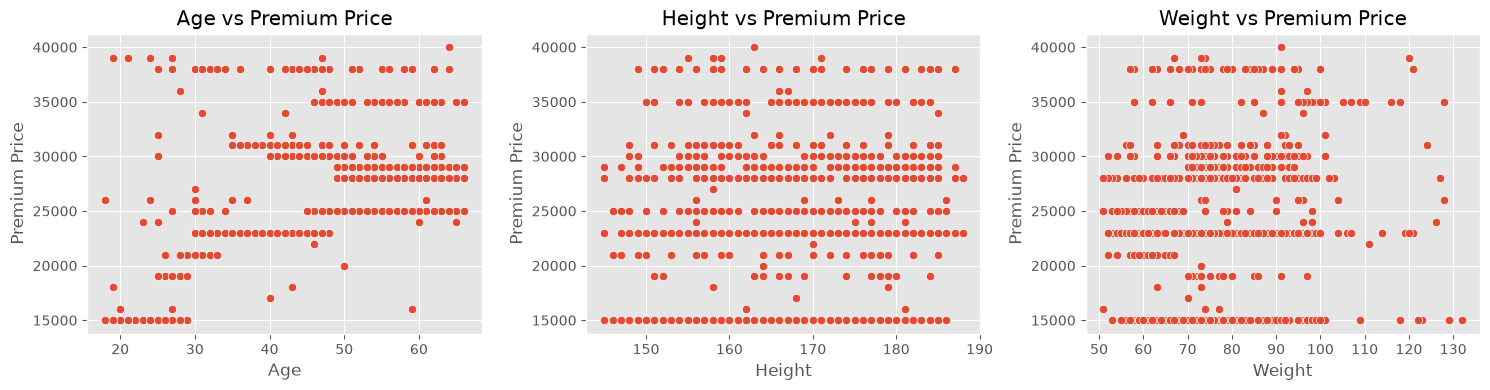

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Age vs Premium Price ---
sns.scatterplot(data=df, x="Age", y="PremiumPrice", ax=axes[0])
axes[0].set_title("Age vs Premium Price")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Premium Price")

# --- Height vs Premium Price ---
sns.scatterplot(data=df, x="Height", y="PremiumPrice", ax=axes[1])
axes[1].set_title("Height vs Premium Price")
axes[1].set_xlabel("Height")
axes[1].set_ylabel("Premium Price")

# --- Weight vs Premium Price ---
sns.scatterplot(data=df, x="Weight", y="PremiumPrice", ax=axes[2])
axes[2].set_title("Weight vs Premium Price")
axes[2].set_xlabel("Weight")
axes[2].set_ylabel("Premium Price")

plt.tight_layout()
plt.show()

Observation:

* Premium Price of insurance cost increases when age increases.
* There is no clear relationship between Height and Premium Price.
* There is no clear relationship between Weight and Premium Price.

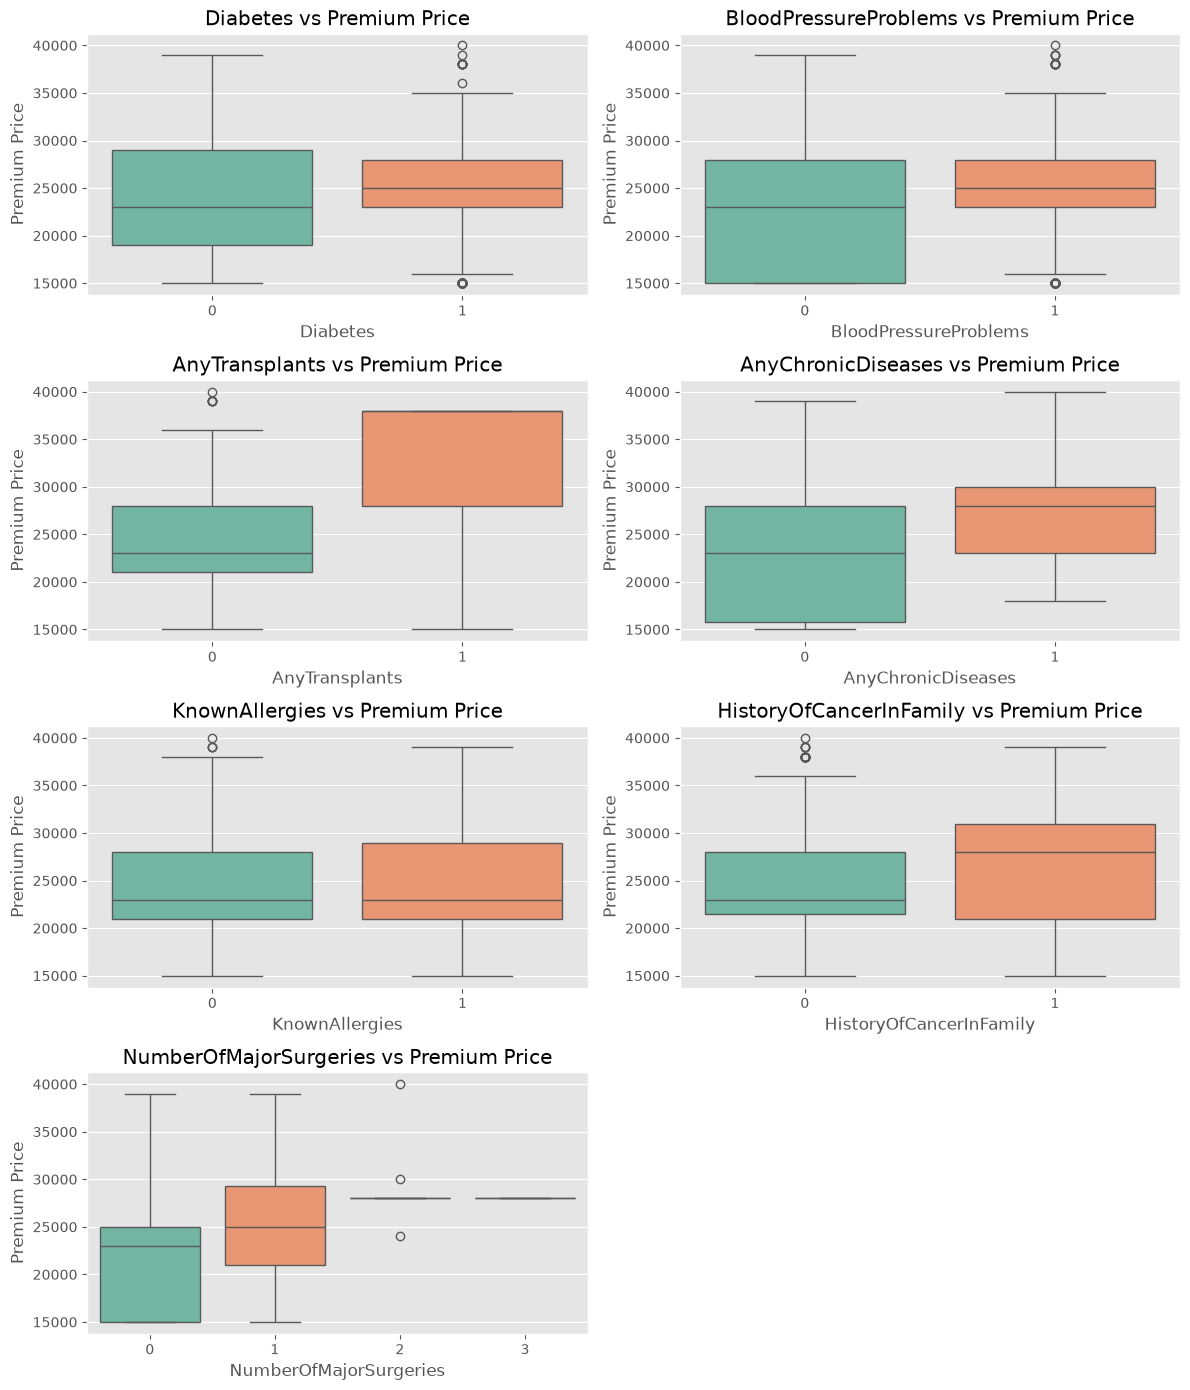

In [101]:
x = ['Diabetes', 'BloodPressureProblems', 'AnyTransplants',
     'AnyChronicDiseases', 'KnownAllergies',
     'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries']

fig, axes = plt.subplots(len(x)//2 + len(x)%2, 2, figsize=(12, 14))
axes = axes.flatten()

for i, col in enumerate(x):
    sns.boxplot(x=col, y="PremiumPrice", hue=col, data=df,
                palette="Set2", legend=False, ax=axes[i])
    axes[i].set_title(f"{col} vs Premium Price")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Premium Price")

# Remove unused axes
for j in range(len(x), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observation:

* Across all seven boxplots, premium prices tend to be higher for individuals with medical conditions compared to those without.

* Diabetes, blood pressure problems, chronic diseases, and transplants show a clear upward shift in median premiums, meaning insurers charge more for these risk factors.

* Known allergies and family history of cancer have a smaller effect, but still show slightly higher premiums.

* Number of major surgeries shows a stepwise increase — more surgeries are linked to higher premiums and greater variation.

* People with transplants have the highest median premium price compared to all other groups.

Overall, the plots highlight that health conditions and medical history strongly influence insurance premium pricing, with chronic and severe conditions driving the biggest differences.

# Multivariate Analysis(Correlation Analysis)

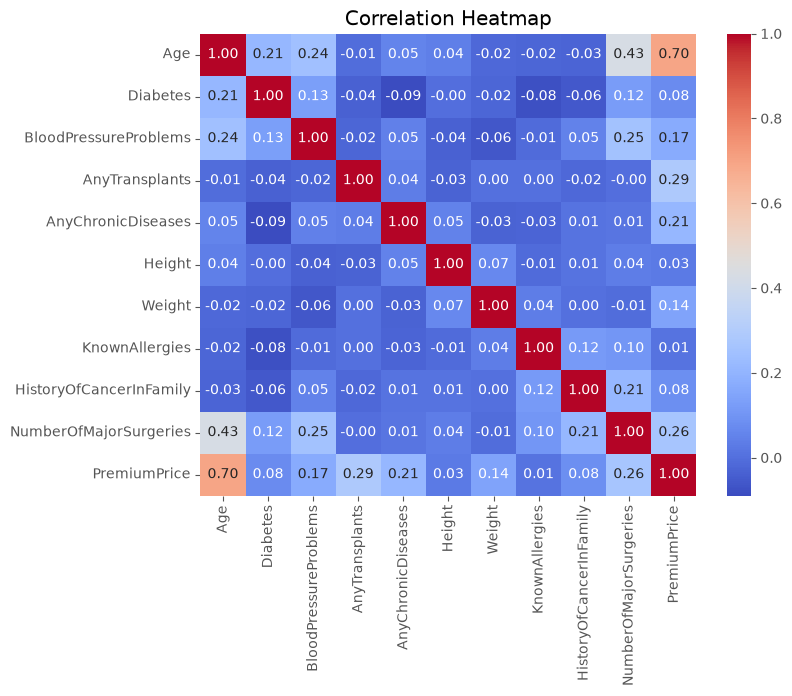

In [106]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [121]:
df.corr()["PremiumPrice"].sort_values(ascending=False)

PremiumPrice               1.000000
Age                        0.697540
AnyTransplants             0.289056
NumberOfMajorSurgeries     0.264250
AnyChronicDiseases         0.208610
BloodPressureProblems      0.167097
Weight                     0.141507
HistoryOfCancerInFamily    0.083139
Diabetes                   0.076209
Height                     0.026910
KnownAllergies             0.012103
Name: PremiumPrice, dtype: float64

# Observations from the Correlation Heatmap
## Strongest Positive Correlation:

* The variable with the strongest positive correlation to Premium Price is Age (~0.70).
* This means older individuals tend to pay higher premiums.

## Weakest Relationship:

* Variables like Height and Weight show correlations close to 0, meaning they have the weakest relationship with Premium Price.
* They don’t significantly influence insurance costs in this dataset.

## Highly Correlated Predictors:

* Age and Premium Price are highly correlated.
* Age and Number of Major Surgeries (~0.43) also show a notable positive correlation, suggesting surgeries increase with age.
* Other health conditions (Diabetes, Blood Pressure Problems, Chronic Diseases) have moderate positive correlations with Premium Price, but none are as strong as Age.

# EDA Summary

1. The dataset contains no significant data quality issues. No missing values or duplicate records were identified, and all variables were stored in appropriate numerical formats.

2. Correlation analysis indicates that **Age** has the strongest positive relationship with **PremiumPrice** among the available predictors.

3. Visual analysis suggests that health-related variables such as **Diabetes**, **BloodPressureProblems**, and **AnyChronicDiseases** are associated with differences in insurance premium levels. These relationships will be statistically validated during hypothesis testing.

4. **Height** and **Weight** exhibit relatively weak relationships with **PremiumPrice**, although **Weight** contains a small number of potential outliers identified during the IQR analysis.

5. Customers with a greater **NumberOfMajorSurgeries** generally tend to have higher insurance premiums, indicating that surgical history may be an important predictor of premium pricing.

6. Outlier analysis identified **16 potential outliers in Weight** and **6 potential outliers in PremiumPrice**. These observations were retained during the EDA stage because they may represent genuine high-risk customers rather than data entry errors.

### Conclusion

The exploratory data analysis provided a comprehensive understanding of the dataset and identified key variables that may influence insurance premium pricing. These findings will guide the hypothesis testing, feature engineering, and machine learning stages of the project.